<a href="https://colab.research.google.com/github/JMCVALE/ASN-ROCKS-/blob/main/MONITORAMENTO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A base é muito grande para ser colocada no drive e mandada para o colab.

In [7]:
from google.colab import files
uploaded = files.upload()

Saving 2_envio_case_base_Total_2026.csv to 2_envio_case_base_Total_2026.csv


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp

In [9]:
base = pd.read_csv("2_envio_case_base_Total_2026.csv", sep=';')
base.head()

,id,ano_mes,idade_veiculo,marca,vl_bem,idade,estado_civil,qt_restr,renda,Regiao,Profissao,entrada,prazo,pmt,target,FPD,score,contratado
0,534521536,202301,3_5,Chevrolet,"(25000, 70000]",43,solteiro,0,18422,SE,liberais,20,12,2775,0.0,0.0,8,1
1,894445785,202301,10,Chevrolet,"(25000, 70000]",39,solteiro,0,11175,N,empresarios,20,48,734,0.0,0.0,5,1
2,510004819,202301,1_2,Fiat,"(25000, 70000]",37,solteiro,>2,26031,NE,consignados,30,36,1510,1.0,0.0,7,1
3,230978528,202301,10,VW,"(25000, 70000]",61,casado,0,3009,SE,empresarios,20,36,1588,1.0,0.0,4,1
4,489909079,202301,3_5,Fiat,"(25000, 70000]",48,casado,2,10253,CO,assalariados,30,12,2712,0.0,0.0,8,1


In [10]:
base['ano_mes'] = pd.to_datetime(base['ano_mes'], format='%Y%m')

**VARIÁVEL TARGET**

Se o contrato foi inadimplente (1) ou não (0). Se estiver vazio é porque o contrato não foi efetivado

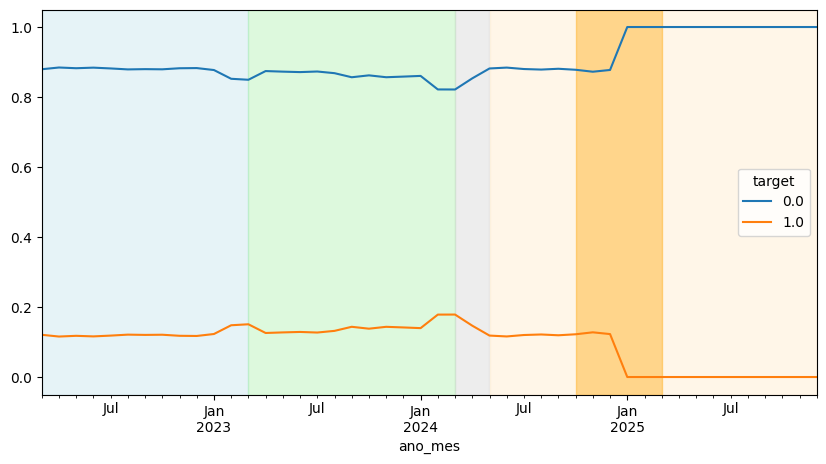

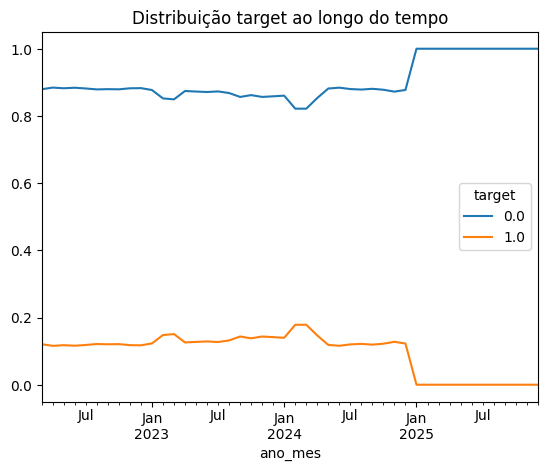

In [22]:
tabela = pd.crosstab(base['ano_mes'], base['target'], normalize='index')

ax = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3) # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3) # janela de observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4) # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # foi implatado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4) # deu ruim

tabela.plot()
plt.title('Distribuição target ao longo do tempo')
plt.show()

In [24]:
# Criar tabela dinâmica com contagem de IDs por ano_mes e score
distribuicao_por_score = pd.pivot_table(
    base,
    values='id',
    index='ano_mes',
    columns='score',
    aggfunc='count',
    fill_value=0
)

# Calcular o total por ano_mes
distribuicao_por_score['Total'] = distribuicao_por_score.sum(axis=1)

# Calcular percentuais (count id em %) - dividindo cada célula pelo total da linha
tabela_distribuicao_por_score = distribuicao_por_score.div(distribuicao_por_score['Total'], axis=0) * 100
tabela_distribuicao_por_score = tabela_distribuicao_por_score.round(2)  # Arredondar para 2 casas decimais

# Ordenar por ano_mes
tabela_distribuicao_por_score = tabela_distribuicao_por_score.sort_index()

# Visualizar a tabela percentual
print("Tabela Dinâmica - Distribuição % de clientes por ano_mes x score:")

tabela_distribuicao_por_score

Tabela Dinâmica - Distribuição % de clientes por ano_mes x score:


score,1,2,3,4,5,6,7,8,9,10,Total
ano_mes,,,,,,,,,,,
2022-03-01,3.04,4.05,7.01,8.82,13.17,15.86,21.43,15.37,9.05,2.20,100.0
2022-04-01,3.40,3.83,6.84,9.01,12.97,15.75,21.09,15.97,8.91,2.24,100.0
2022-05-01,3.04,4.13,7.05,9.05,12.87,15.89,20.62,16.00,9.24,2.13,100.0
2022-06-01,2.84,4.17,6.72,8.98,13.40,16.38,21.11,15.38,8.97,2.05,100.0
2022-07-01,2.85,4.09,7.05,8.53,13.06,15.74,21.05,16.43,9.07,2.12,100.0
2022-08-01,3.01,3.91,6.94,8.82,13.31,16.16,21.14,15.69,8.92,2.13,100.0
2022-09-01,3.04,3.65,7.42,8.83,12.74,15.22,21.76,16.27,8.87,2.20,100.0
2022-10-01,2.74,4.09,7.22,8.99,13.00,15.72,21.16,15.78,8.94,2.36,100.0
2022-11-01,2.87,3.79,7.10,8.97,13.06,16.24,20.96,15.75,9.11,2.15,100.0


O target ainda não maturou, ou seja, não temos se inadimpliu ou não.

ConversionError: Failed to convert value(s) to axis units: ['2024-05-01', Timestamp('2025-12-01 00:00:00')]

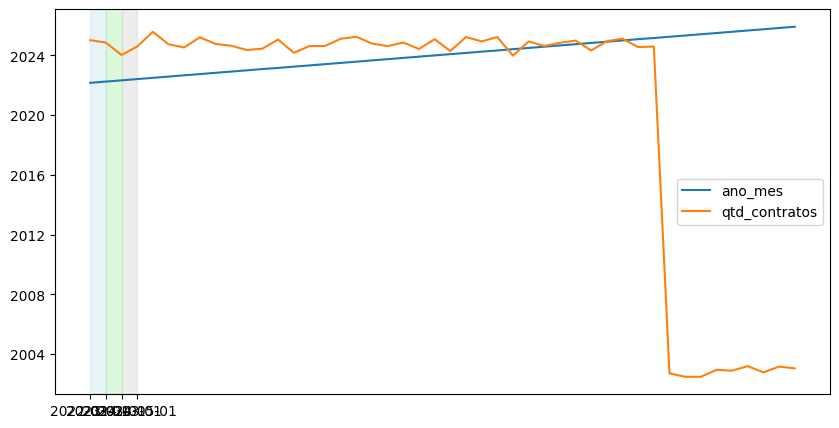

In [36]:
contratos_tempo = base.groupby('ano_mes')['id'].count().reset_index()
contratos_tempo.columns = ['ano_mes','qtd_contratos']
contratos_tempo

ax = contratos_tempo.plot(figsize=(10,5))

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3) # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3) # janela de observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4) # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # foi implatado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4) # deu ruim

plt.title('Volume de contratos ao longo do tempo')
plt.ylim(0,22000)
plt.show()

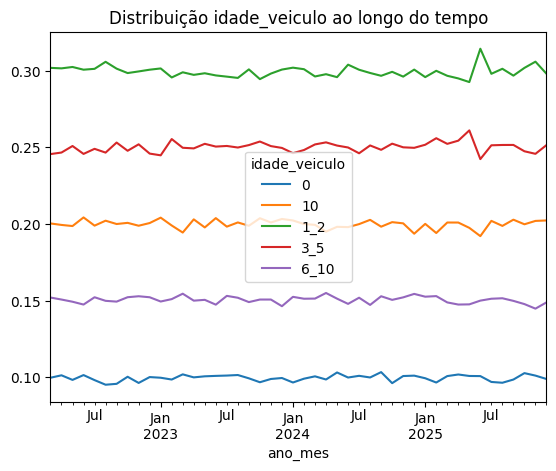

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['idade_veiculo'], normalize='index')

tabela.plot()
plt.title('Distribuição idade_veiculo ao longo do tempo')
plt.show()

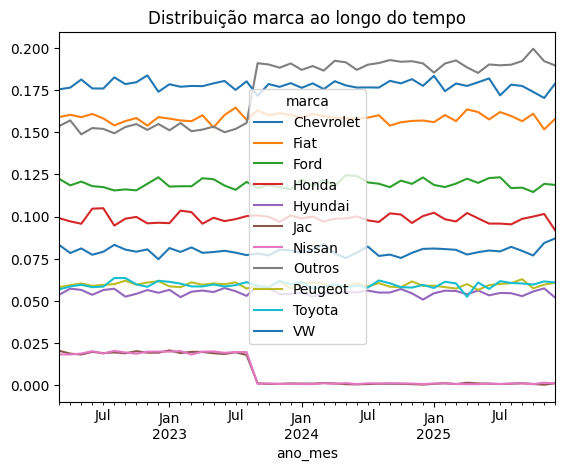

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['marca'], normalize='index')

tabela.plot()
plt.title('Distribuição marca ao longo do tempo')
plt.show()

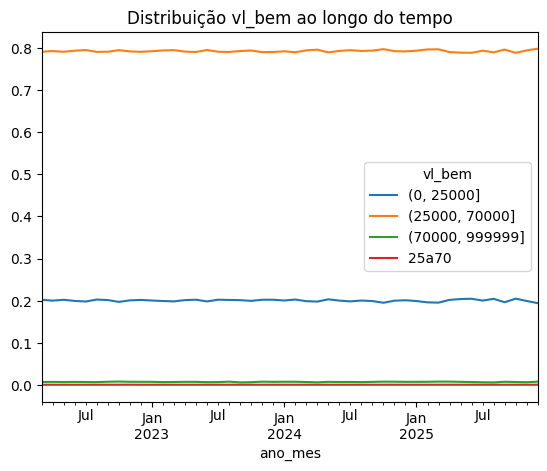

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['vl_bem'], normalize='index')

tabela.plot()
plt.title('Distribuição vl_bem ao longo do tempo')
plt.show()

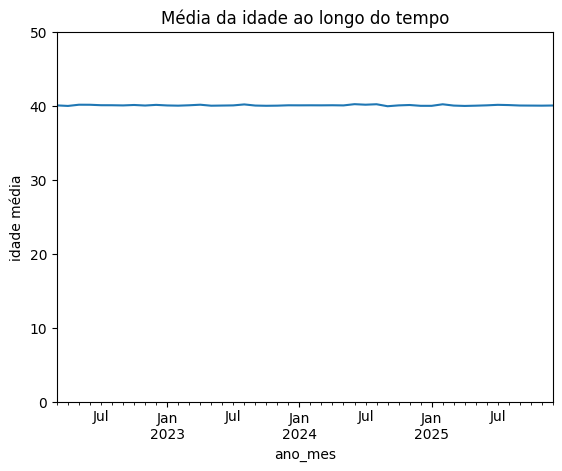

In [ ]:
idade_tempo = base.groupby('ano_mes')['idade'].mean()

idade_tempo.plot()
plt.title('Média da idade ao longo do tempo')
plt.xlabel('ano_mes')
plt.ylabel('idade média')
plt.ylim(0,50)
plt.show()

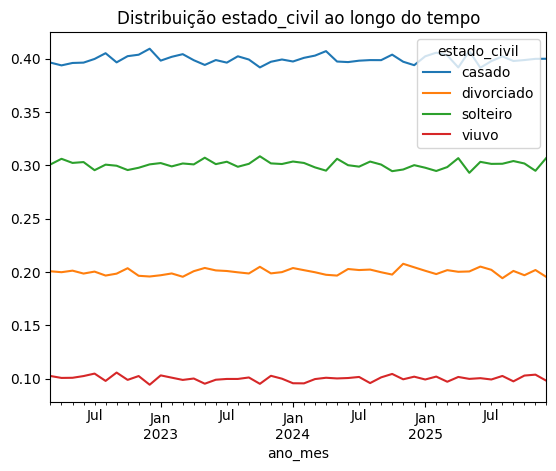

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['estado_civil'], normalize='index')

tabela.plot()
plt.title('Distribuição estado_civil ao longo do tempo')
plt.show()

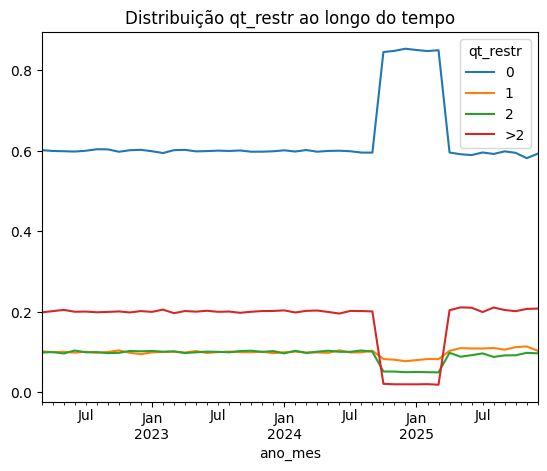

In [13]:
tabela = pd.crosstab(base['ano_mes'], base['qt_restr'], normalize='index')

tabela.plot()
plt.title('Distribuição qt_restr ao longo do tempo')
plt.show()

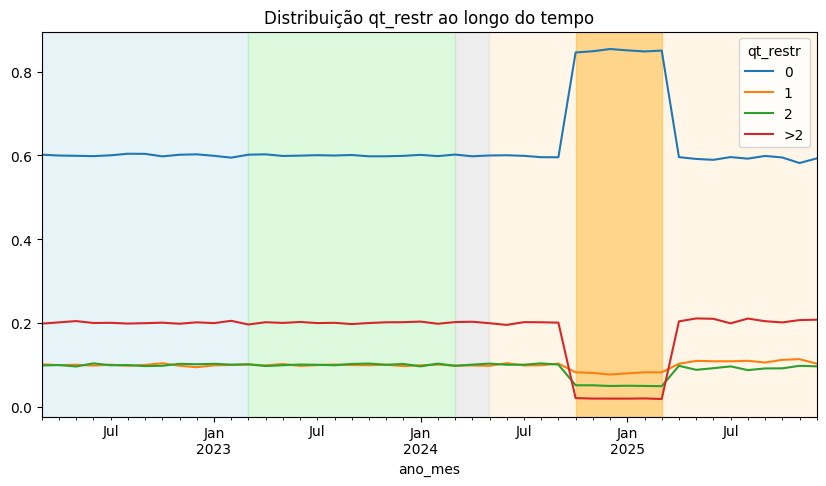

In [21]:
# garantir formato de data
base['ano_mes'] = pd.to_datetime(base['ano_mes'])

tabela = pd.crosstab(base['ano_mes'], base['qt_restr'], normalize='index')

ax = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3) # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3) # janela de observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4) # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # foi implatado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4) # deu ruim

plt.title('Distribuição qt_restr ao longo do tempo')
plt.show()

A variável qt_restr apresenta estabilidade ao longo da maior parte do período analisado. Entretanto, observa-se uma ruptura temporária na distribuição por volta de 2025, quando a proporção de clientes sem restrições aumenta significativamente, enquanto as demais categorias praticamente desaparecem. Esse comportamento pode indicar mudança na política de crédito ou inconsistência na captura da variável naquele período.

In [34]:
# Filtrar o DataFrame base primeiro
base_filtrada = base[base['vl_bem'] == '>2'].copy()

# Criar a tabela dinâmica com o DataFrame filtrado
distribuicao_por_score = pd.pivot_table(
    base_filtrada,
    values='id',
    index='ano_mes',
    columns='score',
    aggfunc='count',
    fill_value=0
)

# Calcular o total por ano_mes
distribuicao_por_score['Total'] = distribuicao_por_score.sum(axis=1)

# Calcular percentuais (count id em %) - dividindo cada célula pelo total da linha
tabela_distribuicao_por_score = distribuicao_por_score.div(distribuicao_por_score['Total'], axis=0) * 100
tabela_distribuicao_por_score = tabela_distribuicao_por_score.round(2)

# Ordenar por ano_mes
tabela_distribuicao_por_score = tabela_distribuicao_por_score.sort_index()

# Visualizar a tabela percentual
print("Tabela Dinâmica - Distribuição % de clientes por ano_mes x score")
print(f"(Filtrado para vl_bem == '>2')")
print("="*70)
print(tabela_distribuicao_por_score)

# Opcional: verificar quantos registros foram filtrados
print(f"\nTotal de registros com vl_bem == '>2': {len(base_filtrada)}")
print(f"Total de registros na base original: {len(base)}")
print(f"Percentual: {(len(base_filtrada)/len(base)*100):.2f}%")

Tabela Dinâmica - Distribuição % de clientes por ano_mes x score
(Filtrado para vl_bem == '>2')
Empty DataFrame
Columns: [Total]
Index: []

Total de registros com vl_bem == '>2': 0
Total de registros na base original: 848001
Percentual: 0.00%


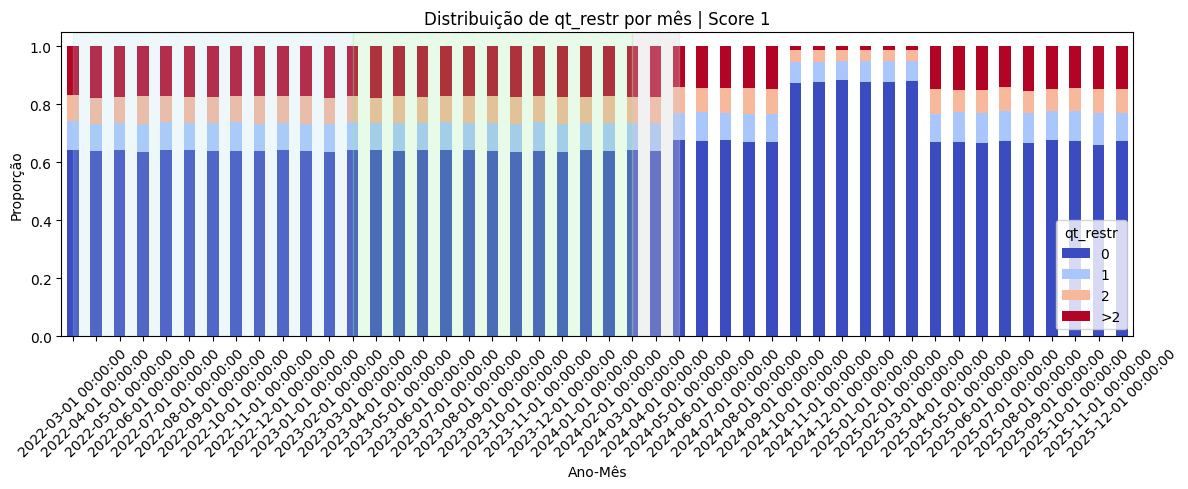

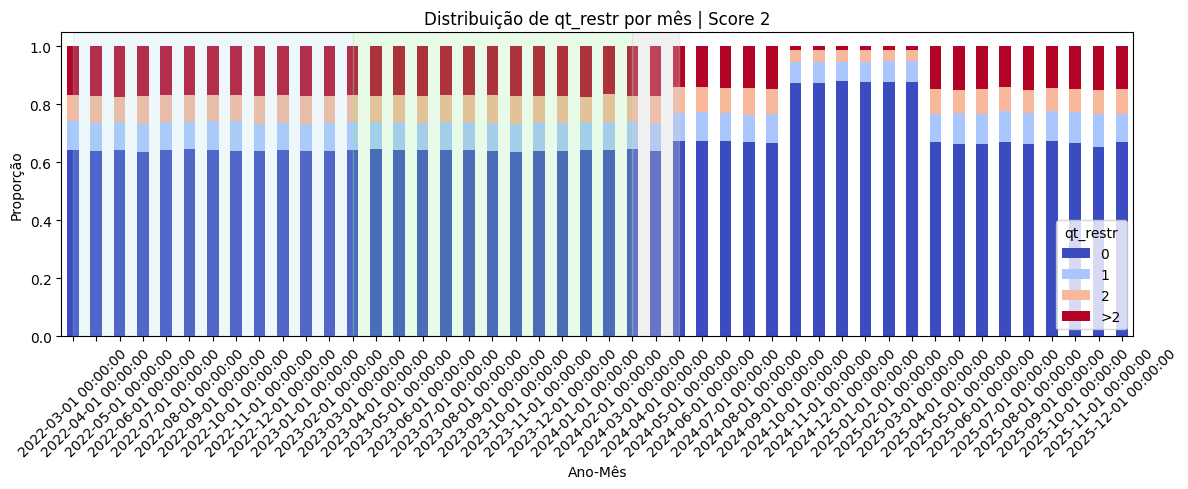

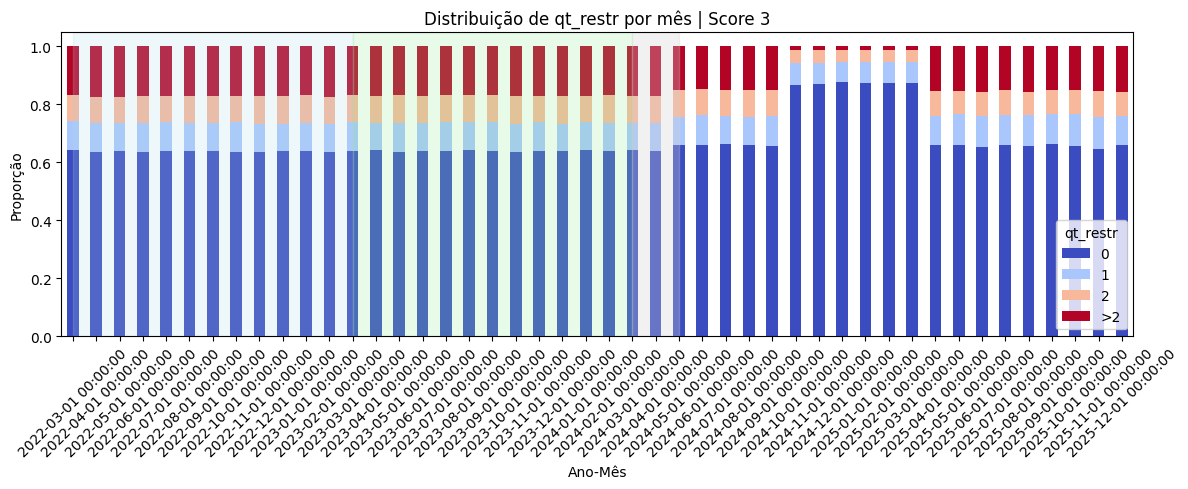

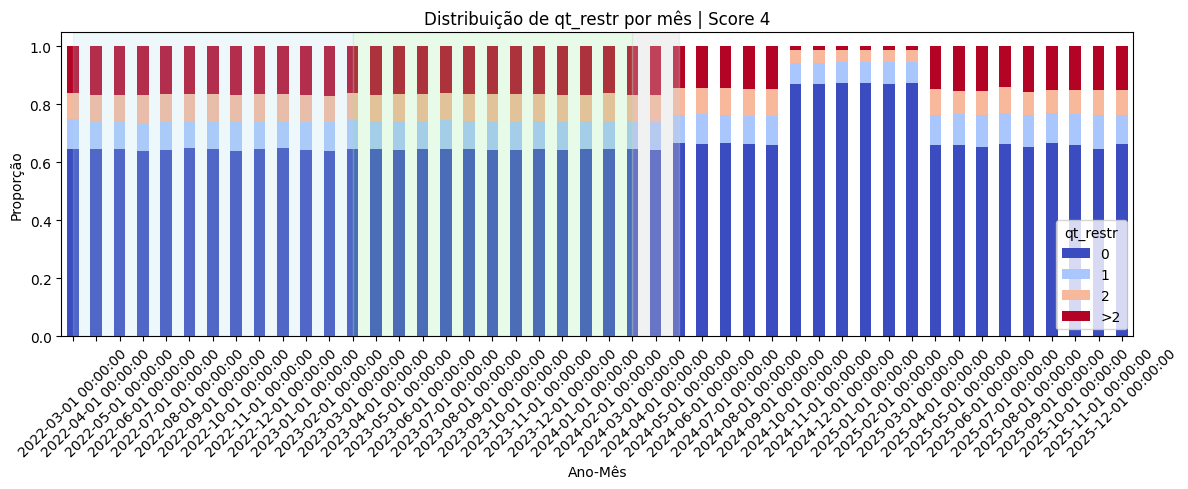

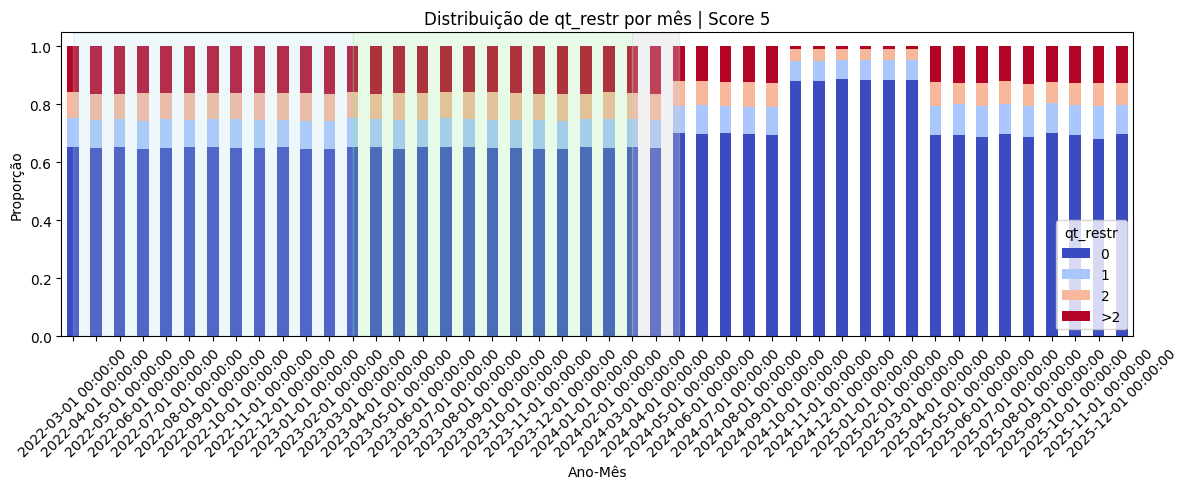

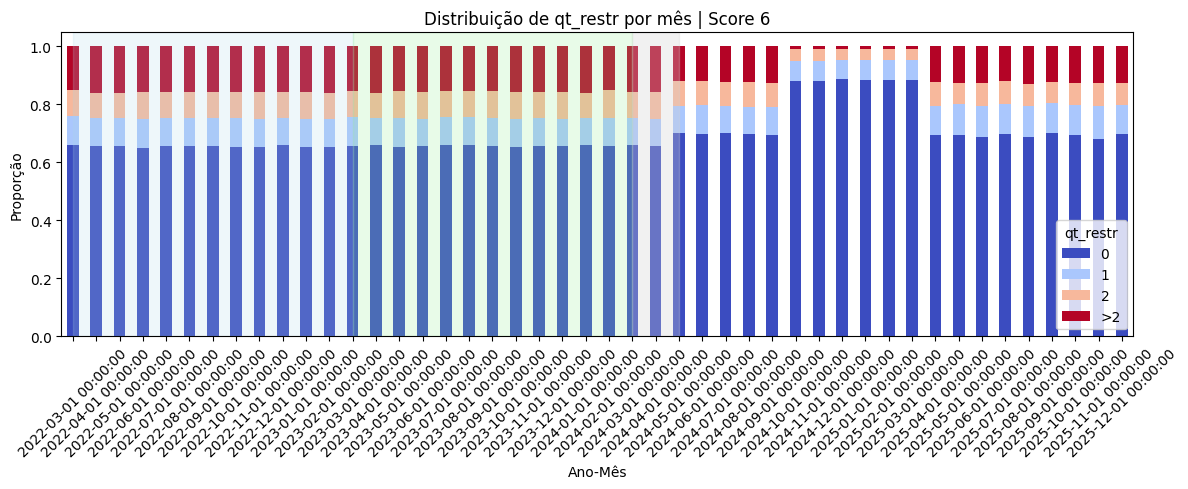

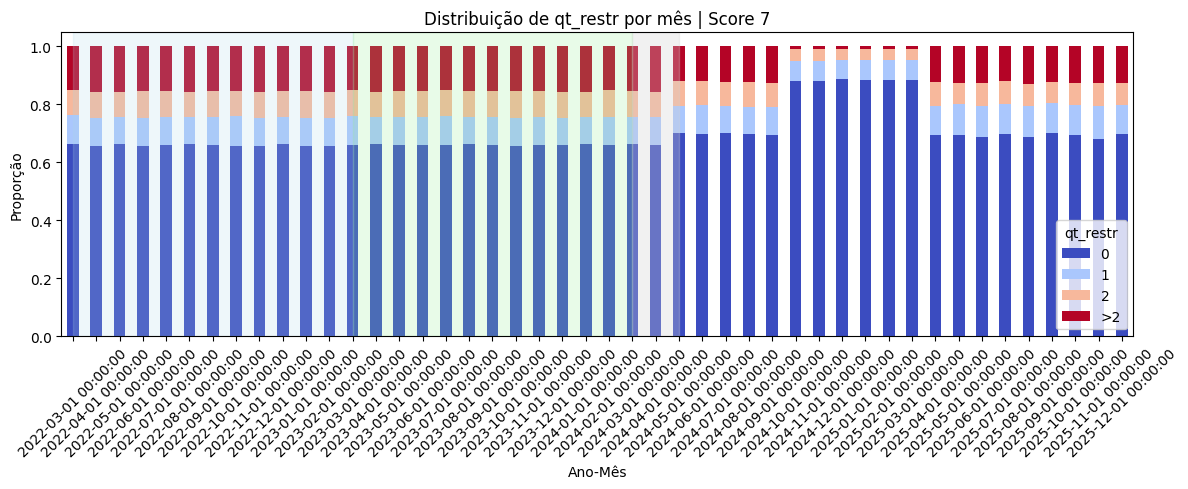

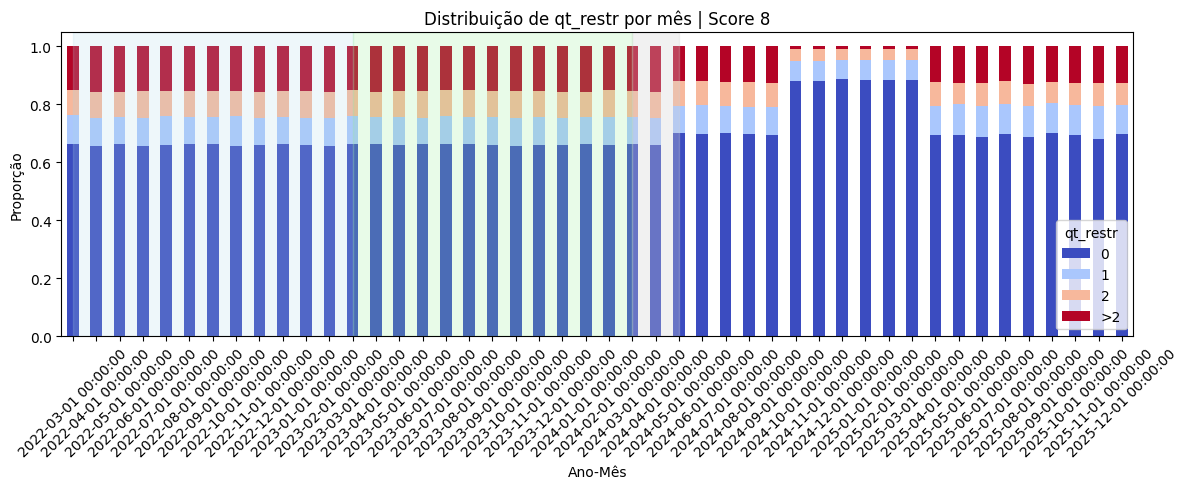

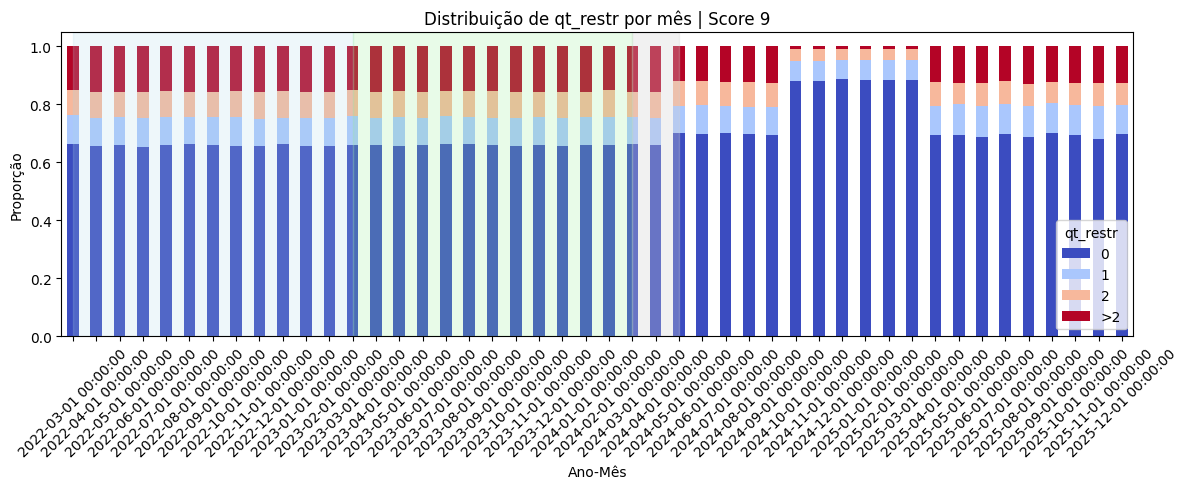

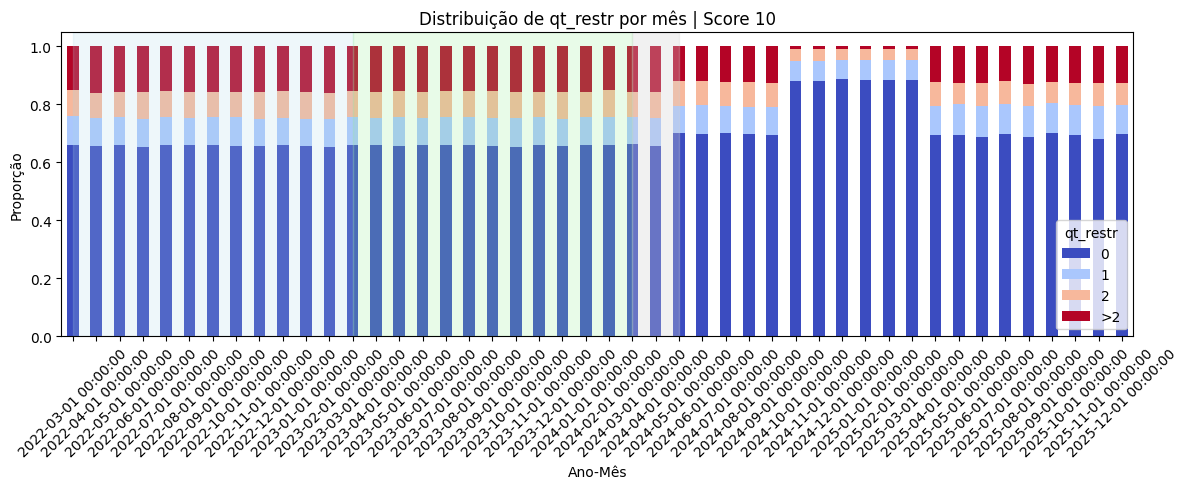

In [40]:
base['ano_mes'] = pd.to_datetime(base['ano_mes'])

for score in sorted(base['score'].dropna().unique()):

    df = base[(base['score'] == score)|(base["contratado"] == 1)]

    tabela = pd.crosstab(df['ano_mes'], df['qt_restr'], normalize='index')

    fig, ax = plt.subplots(figsize=(12,5))

    tabela.plot(kind='bar', stacked=True, ax=ax, colormap='coolwarm')

    # períodos do modelo
    ax.axvspan(0, 12, color='lightblue', alpha=0.2)
    ax.axvspan(12, 24, color='lightgreen', alpha=0.2)
    ax.axvspan(24, 26, color='lightgray', alpha=0.3)

    ax.set_title(f'Distribuição de qt_restr por mês | Score {score}')
    ax.set_ylabel('Proporção')
    ax.set_xlabel('Ano-Mês')

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

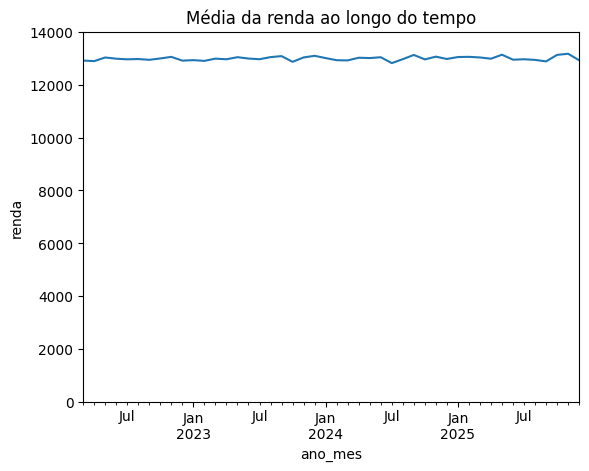

In [ ]:
renda_tempo = base.groupby('ano_mes')['renda'].mean()

renda_tempo.plot()
plt.title('Média da renda ao longo do tempo')
plt.xlabel('ano_mes')
plt.ylabel('renda')
plt.ylim(0,14000)
plt.show()

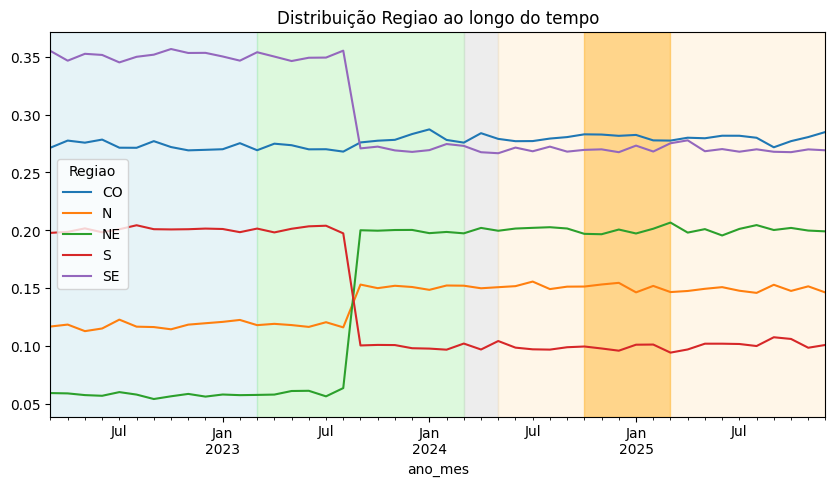

In [38]:
tabela = pd.crosstab(base['ano_mes'], base['Regiao'], normalize='index')

ax = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
ax.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3) # modelagem
ax.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3) # janela de observação
ax.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4) # limbo
ax.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # foi implatado
ax.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4) # deu ruim

plt.title('Distribuição Regiao ao longo do tempo')
plt.show()

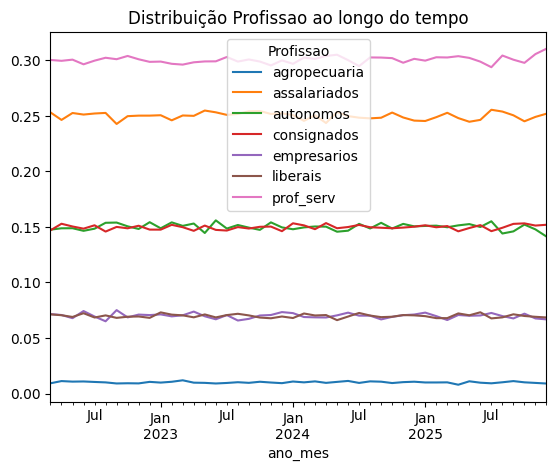

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['Profissao'], normalize='index')

tabela.plot()
plt.title('Distribuição Profissao ao longo do tempo')
plt.show()

In [ ]:
base['entrada'].unique()

array([20, 30, 40, 50, 10,  0])

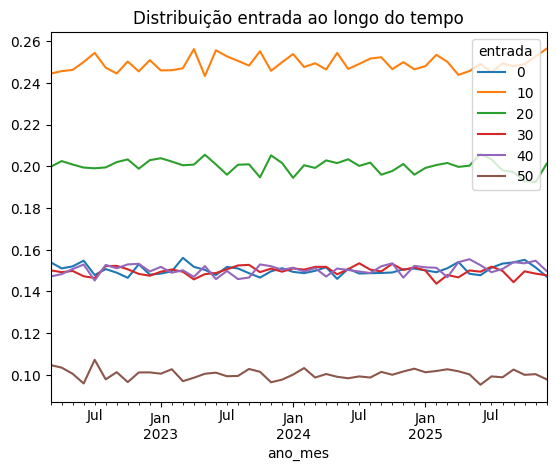

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['entrada'], normalize='index')

tabela.plot()
plt.title('Distribuição entrada ao longo do tempo')
plt.show()

In [ ]:
base['prazo'].unique()

array([12, 48, 36, 24, 60])

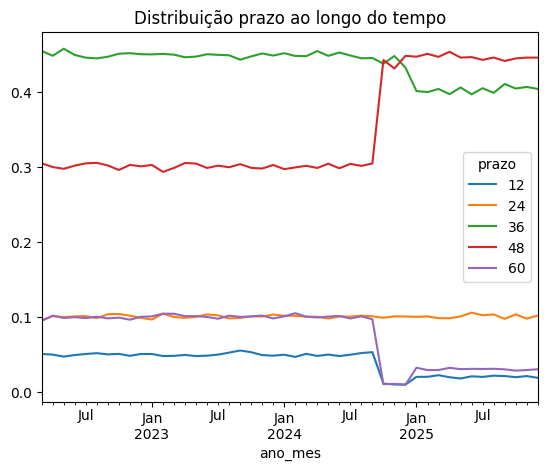

In [ ]:
tabela = pd.crosstab(base['ano_mes'], base['prazo'], normalize='index')

tabela.plot()
plt.title('Distribuição prazo ao longo do tempo')
plt.show()

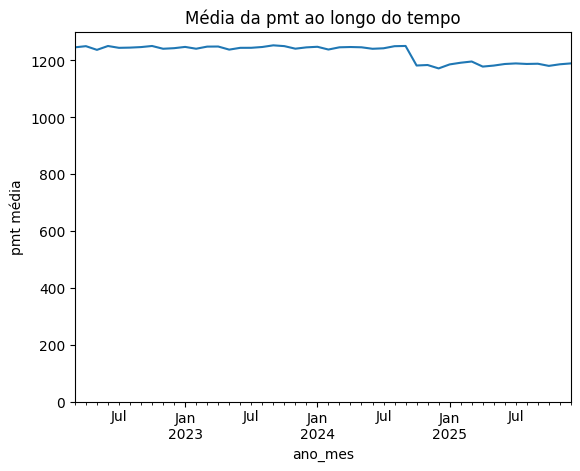

In [ ]:
pmt_tempo = base.groupby('ano_mes')['pmt'].mean()

pmt_tempo.plot()
plt.title('Média da pmt ao longo do tempo')
plt.xlabel('ano_mes')
plt.ylabel('pmt média')
plt.ylim(0,1300)
plt.show()

In [ ]:
base['FPD'].unique()

array([ 0., nan,  1.])

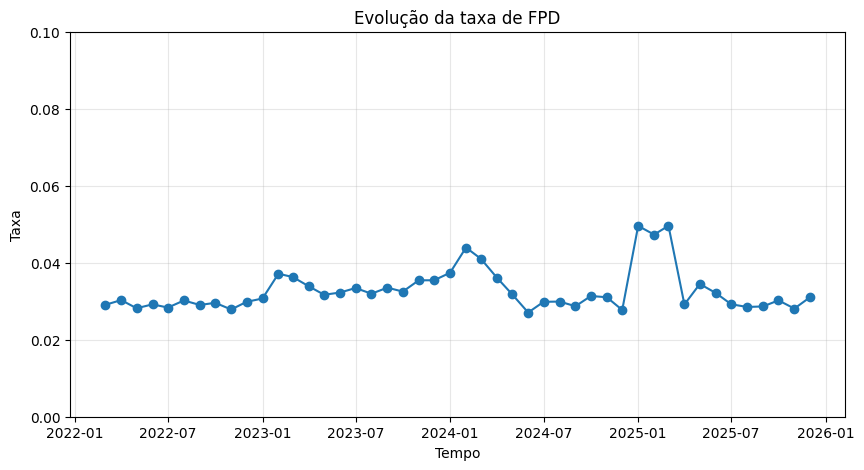

In [ ]:
fpd_tempo = base.groupby('ano_mes')['FPD'].mean()

plt.figure(figsize=(10,5))
plt.plot(fpd_tempo.index, fpd_tempo.values, marker='o')
plt.grid(alpha=0.3)
plt.title('Evolução da taxa de FPD')
plt.ylabel('Taxa')
plt.xlabel('Tempo')
plt.ylim(0,0.1)
plt.show()

In [ ]:
base['score'].unique()

array([ 8,  5,  7,  4,  6,  3,  9,  1,  2, 10])

## **VARIÁVEL SCORE**
Qualidade de crédito baseado no modelo estatístico desenvolvido pelo banco (usando o período de 2017)

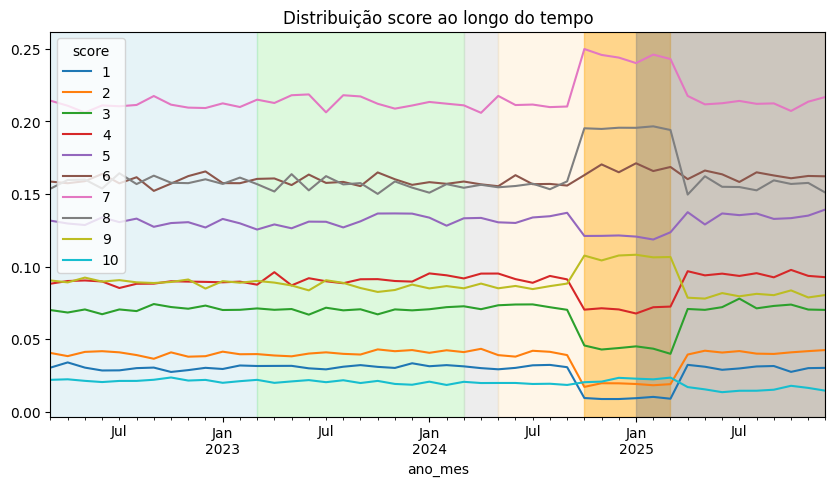

In [30]:
tabela = pd.crosstab(base['ano_mes'], base['score'], normalize='index')

score = tabela.plot(figsize=(10,5))

# pintar fundo dos períodos
score.axvspan('2022-03-01', '2023-03-01', color='lightblue', alpha=0.3) # modelagem
score.axvspan('2023-03-01', '2024-03-01', color='lightgreen', alpha=0.3) # janela de observação
score.axvspan('2024-03-01', '2024-05-01', color='lightgray', alpha=0.4) # limbo
score.axvspan('2024-05-01', tabela.index.max(), color='moccasin', alpha=0.3) # foi implatado
score.axvspan('2024-10-01', '2025-03-01', color='orange', alpha=0.4) # deu ruim
score.axvspan('2025-01-01', '2025-12-01', color='gray', alpha=0.4) # sem target

plt.title('Distribuição score ao longo do tempo')
plt.show()

In [ ]:
## PSI para a variável SCORE

# usar toda a base que possui score
df = base[base["score"].notna()].copy()

# criar decis de score
df["decil"] = pd.qcut(df["score"], 10, labels=False, duplicates="drop") + 1

# escolher período base (ex: 2023)
base_periodo = df[df["ano_mes"] < "2024-01-01"]

dist_base = base_periodo["decil"].value_counts(normalize=True).sort_index()

psi_lista = []

for mes, dados in df.groupby("ano_mes"):

    dist_mes = dados["decil"].value_counts(normalize=True).sort_index()

    tabela = pd.concat([dist_base, dist_mes], axis=1)
    tabela.columns = ["base", "atual"]

    tabela = tabela.fillna(0.0001)

    tabela["psi"] = (tabela["atual"] - tabela["base"]) * np.log(tabela["atual"] / tabela["base"])

    psi = tabela["psi"].sum()

    psi_lista.append({"ano_mes": mes, "PSI": psi})

psi_tempo = pd.DataFrame(psi_lista)

print(psi_tempo)

      ano_mes       PSI
0  2022-03-01  0.000240
1  2022-04-01  0.000148
2  2022-05-01  0.000463
3  2022-06-01  0.000439
4  2022-07-01  0.000597
5  2022-08-01  0.000156
6  2022-09-01  0.000748
7  2022-10-01  0.000330
8  2022-11-01  0.000267
9  2022-12-01  0.000619
10 2023-01-01  0.000155
11 2023-02-01  0.000148
12 2023-03-01  0.000397
13 2023-04-01  0.000801
14 2023-05-01  0.000675
15 2023-06-01  0.000910
16 2023-07-01  0.000421
17 2023-08-01  0.000302
18 2023-09-01  0.000441
19 2023-10-01  0.001252
20 2023-11-01  0.000768
21 2023-12-01  0.000873
22 2024-01-01  0.000887
23 2024-02-01  0.000913
24 2024-03-01  0.000448
25 2024-04-01  0.000807
26 2024-05-01  0.000827
27 2024-06-01  0.000282
28 2024-07-01  0.000838
29 2024-08-01  0.000835
30 2024-09-01  0.000785
31 2024-10-01  0.069220
32 2024-11-01  0.068360
33 2024-12-01  0.067881
34 2025-01-01  0.067319
35 2025-02-01  0.068486
36 2025-03-01  0.073140
37 2025-04-01  0.003504
38 2025-05-01  0.003771
39 2025-06-01  0.004678
40 2025-07-01  0

In [ ]:
## PSI com carta de controle para a variável SCORE

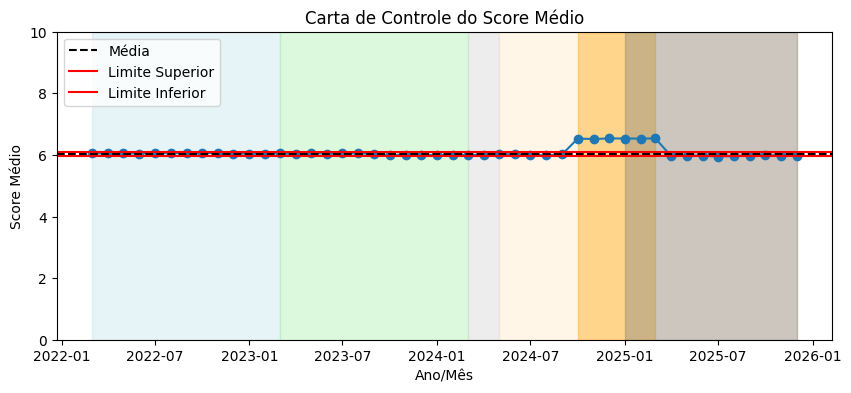

In [42]:
## SCORE MÉDIO com carta de controle para a variável SCORE

score_medio = base.groupby("ano_mes")["score"].mean().reset_index(name="score_medio")

# período de observação (baseline)
obs = score_medio[
    (score_medio["ano_mes"] >= "2023-02-01") &
    (score_medio["ano_mes"] <= "2024-02-01")
]

# média e desvio apenas do período de observação
media = obs["score_medio"].mean()
std = obs["score_medio"].std()

ucl = media + 2*std
lcl = media - 2*std


fig, ax = plt.subplots(figsize=(10,4))

# pintar fundo dos períodos
ax.axvspan(pd.to_datetime('2022-03-01'), pd.to_datetime('2023-03-01'), color='lightblue', alpha=0.3)   # modelagem
ax.axvspan(pd.to_datetime('2023-03-01'), pd.to_datetime('2024-03-01'), color='lightgreen', alpha=0.3)  # observação
ax.axvspan(pd.to_datetime('2024-03-01'), pd.to_datetime('2024-05-01'), color='lightgray', alpha=0.4)   # limbo
ax.axvspan(pd.to_datetime('2024-05-01'), score_medio["ano_mes"].max(), color='moccasin', alpha=0.3)    # implantado
ax.axvspan(pd.to_datetime('2024-10-01'), pd.to_datetime('2025-03-01'), color='orange', alpha=0.4)      # deu ruim
ax.axvspan(pd.to_datetime('2025-01-01'), pd.to_datetime('2025-12-01'), color='gray', alpha=0.4)        # sem target


# linha do score médio
ax.plot(score_medio["ano_mes"], score_medio["score_medio"], marker="o")

# linhas de controle
ax.axhline(media, linestyle="--", color="black", label="Média")
ax.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
ax.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

ax.set_title("Carta de Controle do Score Médio")
ax.set_xlabel("Ano/Mês")
ax.set_ylabel("Score Médio")

ax.set_ylim(0,10)

ax.legend()

plt.show()

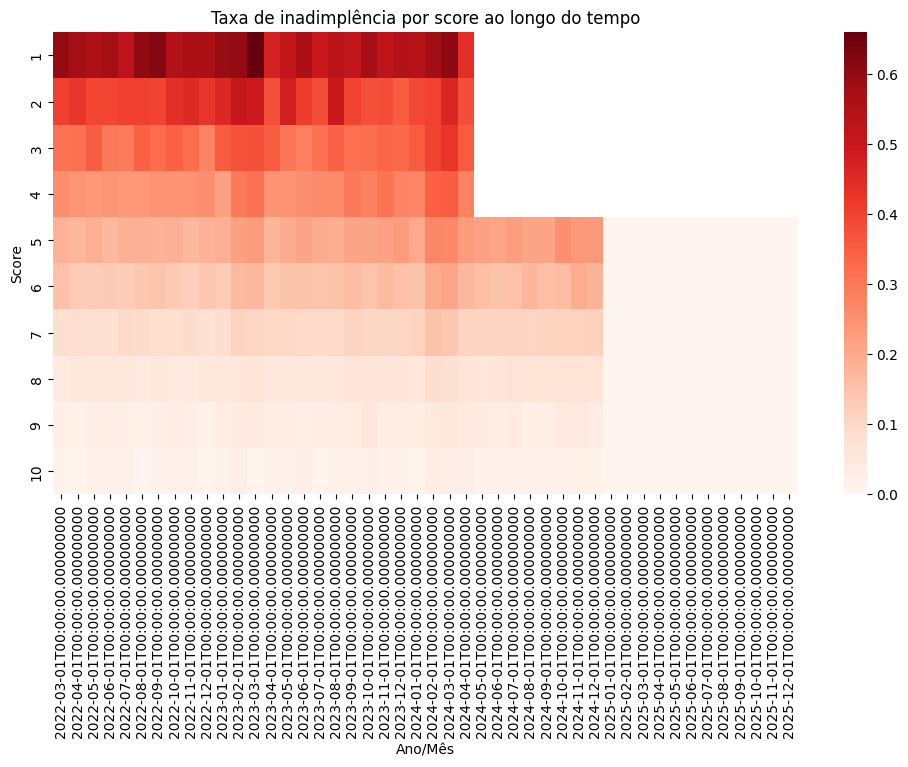

In [ ]:
# taxa de inadimplência por score e mês
taxa = df_model.groupby(["ano_mes","score"])["target"].mean().reset_index()

# transformar em matriz
matriz = taxa.pivot(index="score", columns="ano_mes", values="target")

plt.figure(figsize=(12,6))

sns.heatmap(matriz, cmap="Reds")

plt.title("Taxa de inadimplência por score ao longo do tempo")
plt.xlabel("Ano/Mês")
plt.ylabel("Score")

plt.show()

A análise da taxa de inadimplência por score ao longo do tempo indica que a relação entre score e risco permaneceu consistente. Scores mais baixos continuam apresentando maior inadimplência, enquanto scores elevados mantêm taxas significativamente menores. Isso sugere que o modelo continua ordenando adequadamente o risco, mesmo após a implantação do novo modelo.

In [ ]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(matriz.round(3))

ano_mes  2022-03-01  2022-04-01  2022-05-01  2022-06-01  2022-07-01  \
score                                                                 
1             0.600       0.578       0.558       0.578       0.526   
2             0.403       0.425       0.392       0.392       0.405   
3             0.311       0.316       0.353       0.299       0.295   
4             0.260       0.241       0.238       0.241       0.238   
5             0.183       0.174       0.188       0.168       0.186   
6             0.153       0.130       0.127       0.133       0.125   
7             0.085       0.083       0.078       0.081       0.097   
8             0.045       0.050       0.052       0.051       0.057   
9             0.023       0.022       0.026       0.030       0.024   
10            0.012       0.009       0.022       0.017       0.019   

ano_mes  2022-08-01  2022-09-01  2022-10-01  2022-11-01  2022-12-01  \
score                                                                 
1    

## **VARIÁVEL CONTRATADO**

In [ ]:
base['contratado'].unique()

array([1, 0])

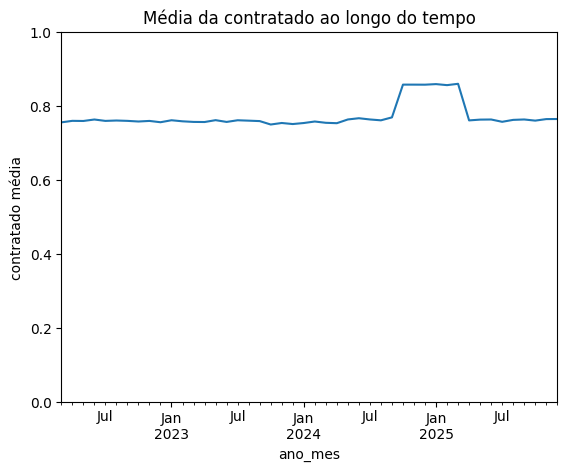

In [ ]:
pmt_tempo = base.groupby('ano_mes')['contratado'].mean()

pmt_tempo.plot()
plt.title('Média da contratado ao longo do tempo')
plt.xlabel('ano_mes')
plt.ylabel('contratado média')
plt.ylim(0,1)
plt.show()

### **PILAR 2: DISCRIMINAÇÃO - KS ao longo do tempo**

In [ ]:
# usar apenas contratos efetivados
df_model = base[base["contratado"] == 1].copy()

# função para calcular KS de um mês
def ks_mes(dados):

    bons = dados[dados["target"] == 0]["score"]
    maus = dados[dados["target"] == 1]["score"]

    if len(bons) == 0 or len(maus) == 0:
        return None

    return ks_2samp(bons, maus).statistic

# KS ao longo do tempo
ks_tempo = df_model.groupby("ano_mes").apply(ks_mes).reset_index(name="KS")

print(ks_tempo)

      ano_mes        KS
0  2022-03-01  0.355225
1  2022-04-01  0.339296
2  2022-05-01  0.345219
3  2022-06-01  0.324022
4  2022-07-01  0.299863
5  2022-08-01  0.339779
6  2022-09-01  0.347479
7  2022-10-01  0.341130
8  2022-11-01  0.324987
9  2022-12-01  0.346920
10 2023-01-01  0.315722
11 2023-02-01  0.323722
12 2023-03-01  0.331741
13 2023-04-01  0.299153
14 2023-05-01  0.318042
15 2023-06-01  0.311042
16 2023-07-01  0.320967
17 2023-08-01  0.319731
18 2023-09-01  0.296300
19 2023-10-01  0.292812
20 2023-11-01  0.323195
21 2023-12-01  0.310754
22 2024-01-01  0.294877
23 2024-02-01  0.294533
24 2024-03-01  0.318660
25 2024-04-01  0.308191
26 2024-05-01  0.238276
27 2024-06-01  0.225360
28 2024-07-01  0.239862
29 2024-08-01  0.255181
30 2024-09-01  0.234896
31 2024-10-01  0.242635
32 2024-11-01  0.255290
33 2024-12-01  0.246508
34 2025-01-01       NaN
35 2025-02-01       NaN
36 2025-03-01       NaN
37 2025-04-01       NaN
38 2025-05-01       NaN
39 2025-06-01       NaN
40 2025-07-01   

/tmp/ipykernel_155/1652430194.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ks_tempo = df_model.groupby("ano_mes").apply(ks_mes).reset_index(name="KS")


A análise da distribuição do target ao longo do tempo mostra ausência de inadimplência observada nos meses mais recentes da base. Isso ocorre porque os contratos ainda não tiveram tempo suficiente para maturar o evento de default. Dessa forma, métricas de discriminação como KS não podem ser avaliadas nesses períodos.

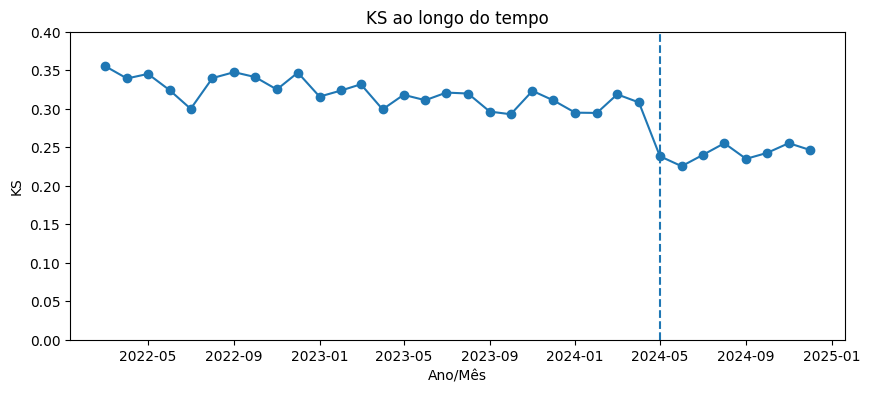

In [ ]:
plt.figure(figsize=(10,4))

plt.plot(ks_tempo["ano_mes"], ks_tempo["KS"], marker="o")

plt.axvline(pd.to_datetime("2024-05-01"), linestyle="--")

plt.title("KS ao longo do tempo")
plt.ylabel("KS")
plt.xlabel("Ano/Mês")
plt.ylim(0,0.4)
plt.show()

In [ ]:
ks_antes = ks_tempo[ks_tempo["ano_mes"] < "2024-05-01"]["KS"].mean()
ks_depois = ks_tempo[ks_tempo["ano_mes"] >= "2024-05-01"]["KS"].mean()

print("KS médio antes:", ks_antes)
print("KS médio depois:", ks_depois)

KS médio antes: 0.32089854772740023
KS médio depois: 0.24225103429442552


*   O modelo apresentou KS médio de aproximadamente 0.32 durante o período de desenvolvimento (modelo + observação);
*   Após a implantação em mai/2024, o KS caiu para aproximadamente 0.24, indicando perda de discriminação;
*   Possível mudança no perfil da carteira ou drift nas variáveis

In [ ]:
maturacao = df_model.groupby(["ano_mes","target"]).size().unstack()

print(maturacao)

target          0.0     1.0
ano_mes                    
2022-03-01  13346.0  1831.0
2022-04-01  13456.0  1760.0
2022-05-01  13215.0  1763.0
2022-06-01  13448.0  1766.0
2022-07-01  13589.0  1824.0
2022-08-01  13362.0  1841.0
2022-09-01  13304.0  1820.0
2022-10-01  13432.0  1846.0
2022-11-01  13398.0  1789.0
2022-12-01  13313.0  1769.0
2023-01-01  13253.0  1857.0
2023-02-01  12848.0  2230.0
2023-03-01  12922.0  2293.0
2023-04-01  13081.0  1883.0
2023-05-01  13251.0  1936.0
2023-06-01  13151.0  1944.0
2023-07-01  13371.0  1947.0
2023-08-01  13312.0  2022.0
2023-09-01  13005.0  2179.0
2023-10-01  12888.0  2065.0
2023-11-01  12934.0  2166.0
2023-12-01  12811.0  2114.0
2024-01-01  13043.0  2118.0
2024-02-01  12343.0  2679.0
2024-03-01  12497.0  2715.0
2024-04-01  12894.0  2216.0
2024-05-01  13571.0  1823.0
2024-06-01  13361.0  1752.0
2024-07-01  13474.0  1838.0
2024-08-01  13334.0  1845.0
2024-09-01  13563.0  1837.0
2024-10-01  15118.0  2103.0
2024-11-01  14841.0  2173.0
2024-12-01  15095.0 

# **PILAR 2: DISCRIMINAÇÃO - KS + carta de controle ao longo do tempo**

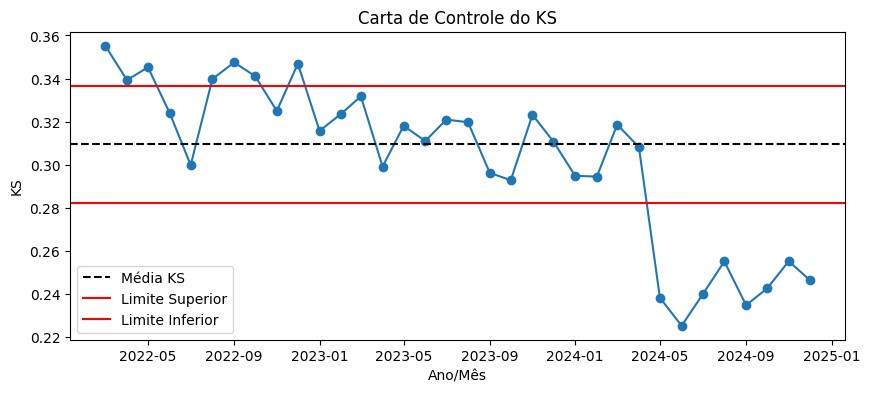

In [ ]:
obs = ks_tempo[
    (ks_tempo["ano_mes"] >= "2023-03-01") &
    (ks_tempo["ano_mes"] <= "2024-02-01")
]

media = obs["KS"].mean()
std = obs["KS"].std()

ucl = media + 2*std
lcl = media - 2*std

plt.figure(figsize=(10,4))

plt.plot(ks_tempo["ano_mes"], ks_tempo["KS"], marker="o")

plt.axhline(media, linestyle="--", color="black", label="Média KS")
plt.axhline(ucl, linestyle="-", color="red", label="Limite Superior")
plt.axhline(lcl, linestyle="-", color="red", label="Limite Inferior")

plt.title("Carta de Controle do KS")
plt.xlabel("Ano/Mês")
plt.ylabel("KS")

plt.legend()

plt.show()

A carta de controle do KS indica comportamento estável do modelo até abril de 2024.
A partir de maio de 2024 observa-se queda abrupta do KS, com valores abaixo do limite inferior de controle. Essa mudança coincide com a implantação do novo modelo, sugerindo perda de capacidade discriminatória.